# Step 2: Exploratory Data Analysis (EDA)

**Goal:** Visualizing the data to ensure our "Fairness Logic" is working correctly.
Before training the model, we must verify that:
1.  **Financial Need:** Poorer students have higher priority scores.
2.  **Social Policy:** Marginalized communities (SC/ST) get the correct policy bonuses.
3.  **Merit:** Higher academic scores correlate with higher priority.

We load the **Raw Data** (not the processed numbers) because it's easier to read "Income: ₹5,00,000" than "Income: -0.45".

In [12]:
# 1. Setup & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual Settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# Load Data (Go up one level to find the CSV)
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data_generation', 'raw_data.csv')

df = pd.read_csv(DATA_PATH)

print(f"Data Loaded: {df.shape[0]} Students")
display(df.head())

Data Loaded: 1000 Students


,Application_ID,Applicant_Name,Family_Income,Caste_Category,Domicile_Maharashtra,Mh_CET_Percentile,JEE_Percentile,University_Test_Score,12th_Percentage,Extracurricular_Score,Scholarship_Priority_Score
0,APP-2025-0001,Sai Patil,596019,General,1,78.83,48.59,100.0,71.3,2,54.5
1,APP-2025-0002,Isha Kulkarni,407192,General,1,44.44,49.07,54.3,77.1,5,60.3
2,APP-2025-0003,Diya Joshi,652530,OBC,1,62.49,65.92,58.8,65.8,1,59.7
3,APP-2025-0004,Sai Chavan,1103301,OBC,1,88.15,75.68,64.1,92.3,6,65.3
4,APP-2025-0005,Aditya Gaikwad,384426,General,0,65.96,44.83,70.9,68.6,3,48.4


## 2. Target Variable Distribution

**What are we looking for?**
We check how the `Scholarship_Priority_Score` is spread across all students.
* **Bell Curve:** We expect a normal distribution (bell shape).
* **Cutoff Check:** The red line shows the cutoff (80+) for a Full Scholarship.

**Insight:**
If the curve is too skewed to the left, it means the scholarship criteria might be too strict. If it's too far right, we might be giving away too much money.

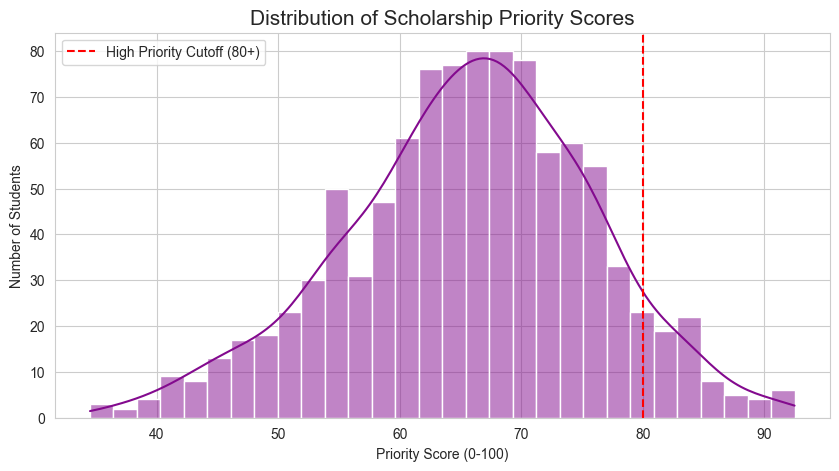

In [14]:

# 2. Target Variable Distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['Scholarship_Priority_Score'], kde=True, color="#830a8e", bins=30)
plt.title('Distribution of Scholarship Priority Scores', fontsize=15)
plt.xlabel('Priority Score (0-100)')
plt.ylabel('Number of Students')

# Add a vertical line for the "Likely Selection" cutoff
plt.axvline(80, color='red', linestyle='--', label='High Priority Cutoff (80+)')
plt.legend()
plt.show()

**Priority Score Distribution:**
Validates that the scoring logic produces a balanced "Bell Curve," ensuring scholarships are neither too easy nor too hard to get, with a clear cutoff for high-priority candidates.

## 3. Financial Need Analysis

**The most critical check:** Does the system actually help the poor?
* **X-Axis:** Family Income (Log Scale).
* **Y-Axis:** Priority Score.

**Insight:**
We should see a **negative correlation**. As Income goes UP (moving right), the Priority Score should go DOWN.
* **Top Left:** Low Income, High Score (This is the target group).
* **Bottom Right:** High Income, Low Score (Rich students get less aid).

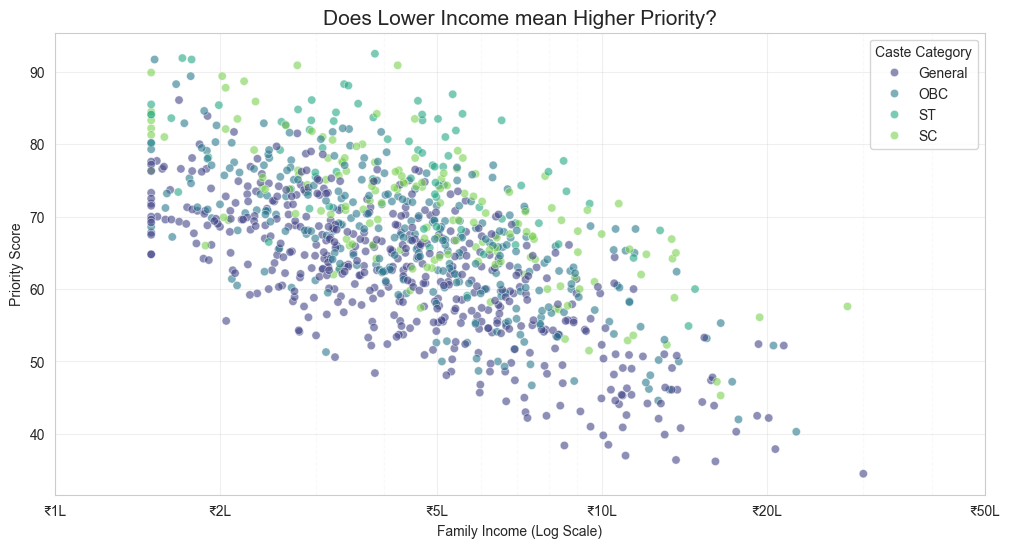

In [15]:
# 3. Financial Need Analysis

plt.figure(figsize=(12, 6))

# Plot Income vs Score
sns.scatterplot(data=df, x='Family_Income', y='Scholarship_Priority_Score', 
                hue='Caste_Category', alpha=0.6, palette='viridis')

# 1. Set Log Scale
plt.xscale('log') 

# 2. FIX: Explicitly define the values you want to see
# We define the raw numbers and the formatted text labels for them
income_values = [100000, 200000, 500000, 1000000, 2000000, 5000000]
income_labels = ['₹1L', '₹2L', '₹5L', '₹10L', '₹20L', '₹50L']

# 3. Apply the ticks and labels directly
plt.xticks(income_values, income_labels)

# 4. Final Formatting
plt.title('Does Lower Income mean Higher Priority?', fontsize=15)
plt.xlabel('Family Income (Log Scale)')
plt.ylabel('Priority Score')

# Use a lighter grid so it doesn't distract from the points
plt.grid(True, which="major", ls="-", alpha=0.3)
plt.grid(True, which="minor", ls="--", alpha=0.1)
plt.legend(title='Caste Category')
plt.show()

**Financial Need Analysis:**
Demonstrates a clear **negative correlation** where lower family income results in higher priority scores, confirming the system effectively targets students with the greatest financial need.

## 4. Social Equity Impact (Caste Analysis)

**Policy Verification:**
Different categories have different reservation bonuses. We use a **Box Plot** to see the median score for each group.

**Insight:**
* **General:** Should have the lowest median baseline.
* **OBC:** Should be slightly higher.
* **SC/ST:** Should have the highest median scores due to affirmative action policies.
* *Note:* Even within "General", there should be high outliers (poor General students with high merit).

C:\Users\rudra\AppData\Local\Temp\ipykernel_4884\1258663622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Caste_Category', y='Scholarship_Priority_Score',


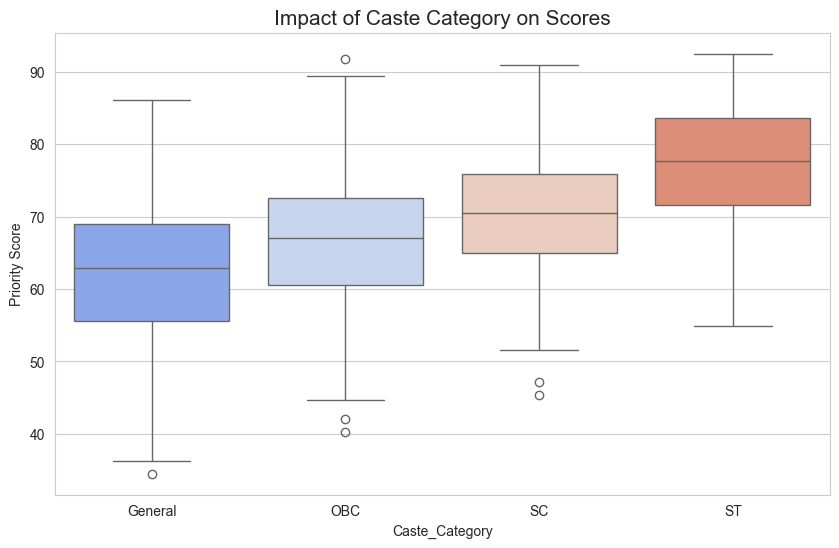

In [16]:

# 4. Social Equity Impact

plt.figure(figsize=(10, 6))
order = ['General', 'OBC', 'SC', 'ST']

sns.boxplot(data=df, x='Caste_Category', y='Scholarship_Priority_Score', 
            order=order, palette="coolwarm")

plt.title('Impact of Caste Category on Scores', fontsize=15)
plt.ylabel('Priority Score')
plt.show()

**Social Equity & Policy Check:**
Visualizes the median score impact across different categories, verifying that the model correctly applies affirmative action bonuses for marginalized groups (SC/ST/OBC) as per university policy.

## 5. Merit vs. Score Analysis

**Does hard work pay off?**
We average the student's academic performance (12th + CET + JEE) and plot it against their Priority Score.

**Insight:**
* The red line should go **UP**.
* A positive slope confirms that **Higher Grades = Higher Scholarship Priority**.
* The scatter is "loose" because even a high-merit student might get a low score if they are very wealthy (which is fair).

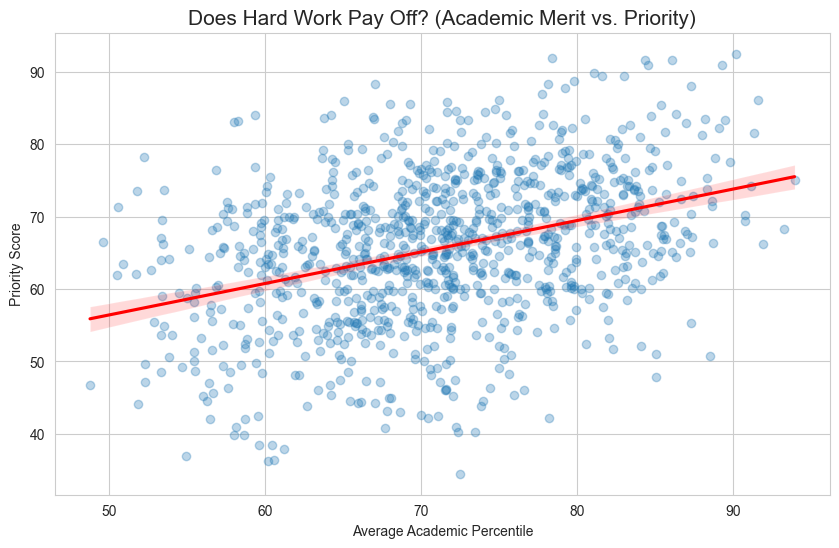

In [17]:

# 5. Merit vs. Score Analysis

# Create a temporary "Average Merit" column just for plotting
df['Avg_Academics'] = (df['Mh_CET_Percentile'] + df['JEE_Percentile'] + df['12th_Percentage']) / 3

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Avg_Academics', y='Scholarship_Priority_Score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Does Hard Work Pay Off? (Academic Merit vs. Priority)', fontsize=15)
plt.xlabel('Average Academic Percentile')
plt.ylabel('Priority Score')
plt.show()

**Meritocracy Check:**
Shows a positive upward trend, confirming that despite financial and social weightings, higher academic performance (Average of 12th/JEE/CET) still significantly boosts a student's scholarship priority.

## 6. Correlation Matrix

**The Mathematical Summary:**
This heatmap shows how every feature relates to every other feature.
* **Red (+1.0):** Strong Positive Correlation (When X goes up, Y goes up).
* **Blue (-1.0):** Strong Negative Correlation (When X goes up, Y goes down).

**Key Takeaways:**
1.  **Income vs. Score:** Should be **Negative (Blue)**.
2.  **Test Scores vs. Score:** Should be **Positive (Red)**.
3.  **Income vs. Test Scores:** Often shows a slight positive correlation (wealthier students often have access to better coaching), which highlights why "Need-Based" aid is necessary to level the playing field.

In [ ]:

# 6. Correlation Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'APP-2025-0001'

<Figure size 1200x800 with 0 Axes>

**Feature Relationships:**
Summarizes how all variables interact, highlighting the strong negative link between **Income** and **Score**, and identifying multicollinearity between **JEE** and **CET** exams (which justifies using Ridge Regression).